In [4]:
# Setting up environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score,
                             ConfusionMatrixDisplay)

In [5]:
print("="*60)
print("  STEP 1 — LOAD DATA")
print("="*60)
 
# Simulate Pima dataset if CSV not present (for portable testing)
try:
    df = pd.read_csv("../data/diabetes.csv")
    print(f"✅ Loaded from file  → shape: {df.shape}")
except FileNotFoundError:
    # Realistic synthetic Pima-like data for demonstration
    print("⚠️  diabetes.csv not found – generating realistic demo data …")
    rng = np.random.RandomState(42)
    n = 768
    # Class proportions: ~35% diabetic
    outcome = rng.binomial(1, 0.35, n)
    df = pd.DataFrame({
        "Pregnancies":           np.clip(rng.poisson(3.8, n),    0, 17),
        "Glucose":               np.where(outcome,
                                     rng.normal(141, 31, n),
                                     rng.normal(109, 26, n)).clip(44, 199).astype(int),
        "BloodPressure":         rng.normal(72, 12, n).clip(24, 122).astype(int),
        "SkinThickness":         np.where(rng.random(n)<0.3, 0,
                                     rng.normal(29, 10, n).clip(7,99)).astype(int),
        "Insulin":               np.where(rng.random(n)<0.49, 0,
                                     rng.exponential(130, n).clip(14,846)).astype(int),
        "BMI":                   np.where(outcome,
                                     rng.normal(35.4, 7.2, n),
                                     rng.normal(30.3, 7.5, n)).clip(18, 60).round(1),
        "DiabetesPedigreeFunction": rng.exponential(0.47, n).clip(0.078, 2.42).round(3),
        "Age":                   rng.randint(21, 82, n),
        "Outcome":               outcome,
    })
    print(f"✅ Demo data generated  → shape: {df.shape}")
 
print(df.head())
print(df.describe())
print("\nClass distribution:")
print(df["Outcome"].value_counts())

  STEP 1 — LOAD DATA
✅ Loaded from file  → shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.3695

In [6]:
# Display data
print("First 5 rows:")
display(df.head())

print("Shape:", df.shape)

print("\nDataset info:")
df.info()

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Shape: (768, 9)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
# Check missing values
print("\nMissing values:")
print(df.isna().sum())

# Features / Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']


Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [8]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# Train model (GINI)
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

In [10]:
# Evaluation
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Evaluation:
Accuracy: 0.69

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.70      0.75        99
           1       0.56      0.69      0.62        55

    accuracy                           0.69       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.72      0.69      0.70       154



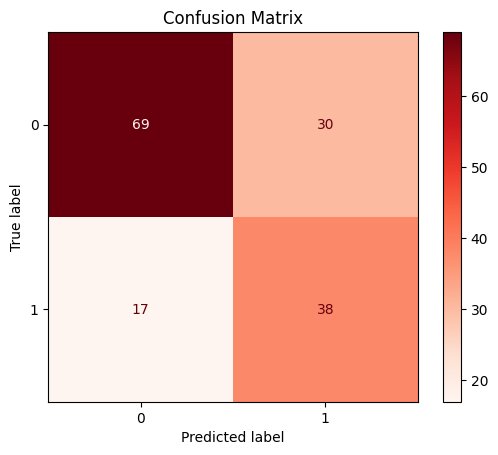

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')
plt.title("Confusion Matrix")
plt.show()

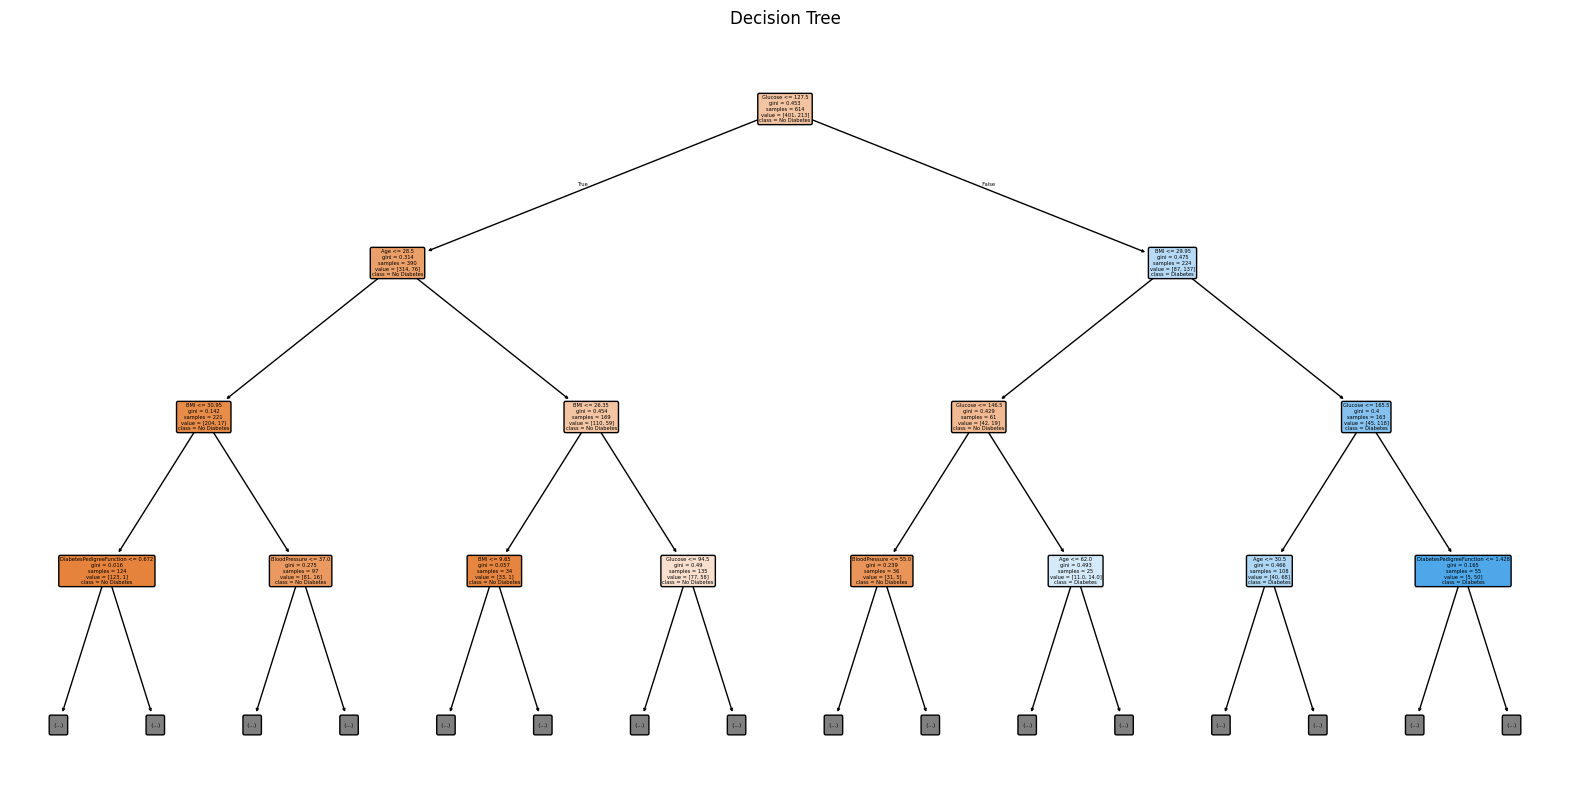

In [12]:
# Tree Visualization
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title("Decision Tree")
plt.show()

In [13]:
# Rules
rules = export_text(model, feature_names=list(X.columns))
print("\nDecision Rules:\n")
print(rules)



Decision Rules:

|--- Glucose <= 127.50
|   |--- Age <= 28.50
|   |   |--- BMI <= 30.95
|   |   |   |--- DiabetesPedigreeFunction <= 0.67
|   |   |   |   |--- class: 0
|   |   |   |--- DiabetesPedigreeFunction >  0.67
|   |   |   |   |--- class: 0
|   |   |--- BMI >  30.95
|   |   |   |--- BloodPressure <= 37.00
|   |   |   |   |--- class: 1
|   |   |   |--- BloodPressure >  37.00
|   |   |   |   |--- class: 0
|   |--- Age >  28.50
|   |   |--- BMI <= 26.35
|   |   |   |--- BMI <= 9.65
|   |   |   |   |--- class: 1
|   |   |   |--- BMI >  9.65
|   |   |   |   |--- class: 0
|   |   |--- BMI >  26.35
|   |   |   |--- Glucose <= 94.50
|   |   |   |   |--- class: 0
|   |   |   |--- Glucose >  94.50
|   |   |   |   |--- class: 1
|--- Glucose >  127.50
|   |--- BMI <= 29.95
|   |   |--- Glucose <= 146.50
|   |   |   |--- BloodPressure <= 55.00
|   |   |   |   |--- class: 1
|   |   |   |--- BloodPressure >  55.00
|   |   |   |   |--- class: 0
|   |   |--- Glucose >  146.50
|   |   |   |--- A

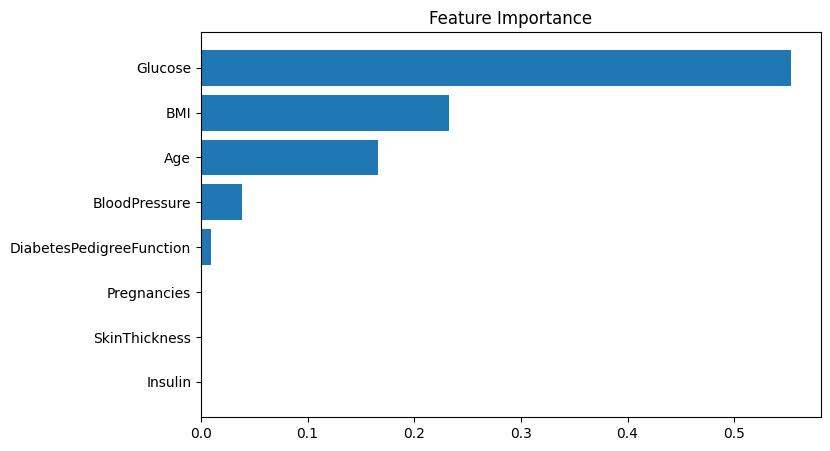

In [14]:
# Feature Importance
importances = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [15]:
print("Criterion used:", model.criterion)

Criterion used: gini


In [17]:
# =========================
# EXPORT MODEL
# =========================

import joblib

# Save the model
model_path = "../models/diabetes_decision_tree.joblib"
joblib.dump(model, model_path)
print(f"✅ Model exported successfully to: {model_path}")

✅ Model exported successfully to: ../models/diabetes_decision_tree.joblib


In [ ]:
# =========================
# GRADIO INTERFACE
# =========================

import gradio as gr

# Prediction function
def predict_diabetes(Pregnancies, Glucose, BloodPressure, SkinThickness,
                     Insulin, BMI, DiabetesPedigreeFunction, Age):

    input_data = np.array([[Pregnancies, Glucose, BloodPressure, SkinThickness,
                            Insulin, BMI, DiabetesPedigreeFunction, Age]])

    prediction = model.predict(input_data)[0]

    if prediction == 1:
        return "⚠️ Diabetic"
    else:
        return "✅ Not Diabetic"


# Interface
interface = gr.Interface(
    fn=predict_diabetes,
    inputs=[
        gr.Slider(0, 20, step=1, label="Pregnancies (0 - 20)"),
        gr.Slider(0, 200, step=1, label="Glucose (0 - 200)"),
        gr.Slider(0, 140, step=1, label="Blood Pressure (0 - 140)"),
        gr.Slider(0, 100, step=1, label="Skin Thickness (0 - 100)"),
        gr.Slider(0, 900, step=1, label="Insulin (0 - 900)"),
        gr.Slider(0, 70, step=0.1, label="BMI (0 - 70)"),
        gr.Slider(0.0, 2.5, step=0.01, label="Diabetes Pedigree Function (0.0 - 2.5)"),
        gr.Slider(1, 120, step=1, label="Age (1 - 120)")
    ],
    outputs="text",
    title="Diabetes Prediction App",
    description="""
Enter patient data to predict diabetes using Decision Tree (Gini Index)

Recommended ranges:
- Pregnancies: 0 to 20
- Glucose: 0 to 200
- Blood Pressure: 0 to 140
- Skin Thickness: 0 to 100
- Insulin: 0 to 900
- BMI: 0 to 70
- Diabetes Pedigree Function: 0.0 to 2.5
- Age: 1 to 120
"""
)

# Launch
interface.launch(share=True)

d:\Education\Esprit\4 IoSyS\2éme Semester\Machine Learning__4IoSyS1\1. Projet\Data Preparation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


d:\Education\Esprit\4 IoSyS\2éme Semester\Machine Learning__4IoSyS1\1. Projet\Data Preparation\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\Education\Esprit\4 IoSyS\2éme Semester\Machine Learning__4IoSyS1\1. Projet\Data Preparation\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
